In [1]:
from torch.utils.data import Dataset, DataLoader
import torch
import tiktoken
import torch.nn as nn

tokenizer=tiktoken.get_encoding("gpt2")


In [6]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [9]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [10]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

NameError: name 'out' is not defined

### Evaluating LLM Performance on real Dataset

In [ ]:
import os 
import urllib.request

file_path="the-verdict.txt"
url="D:\juypterNoteBook\LLM\lectue-9\the-verdict.txt"

if not os.path.exists(file_path):
    with open(r"D:\juypterNoteBook\LLM\lectue-9\the-verdict.txt", "r", encoding="utf-8") as response:
        text_data = response.read()
    with open(file_path,"w",encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path,"r",encoding="utf-8")as file:
        text_data=file.read()

In [ ]:
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [11]:
# total_characters=len(text_data) 

GPT_CONFIG_124m={
    "vocab_size":50247,
    "context_length":256,
    "emb_dim":768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}

# import torch
# train_ratio=0.90
# split_idx=int(train_ratio*len(text_data))
# train_data=text_data[:split_idx]
# val_data=text_data[split_idx:]

# torch.manual_seed(123)

# train_loader=create_dataloader_v1(
#     train_data,
#     batch_size=2,
#     max_length=GPT_CONFIG_124m["context_length"],
#     stride=GPT_CONFIG_124m["context_length"],
#     drop_last=True,
#     shuffle=True,
#     num_workers=0
# )

# val_loader=create_dataloader_v1(
#     val_data,
#     batch_size=2,
#     max_length=GPT_CONFIG_124m["context_length"],
#     stride=GPT_CONFIG_124m["context_length"],
#     drop_last=False,
#     shuffle=False,
#     num_workers=0
# )
# total_tokens=len(tokenizer.encode(text_data))

In [ ]:
if total_tokens * (train_ratio)<GPT_CONFIG_124m["context_length"]:
    print("Not enough token for the training loader."
          "Try to lower the `GPT_CONFIG_12M['context_length']` or"
          "increase the 'training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124m["context_length"]:
    print("Not enough tokens for the validation loader."
          "Try to lower the `GPT_CONFIG_124M['context_length'] or"
          "decrese the `training_ratio`")

In [ ]:
print("Train Loader:")

for x,y in train_loader:
    print(x.shape,y.shape)

print("\n Validation loader:")
for x,y in val_loader:
    print(x.shape,y.shape)
print(len(train_loader))
print(len(val_loader))

Train Loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

 Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])
9
1


In [ ]:
train_tokens=0
for input_batch,target_batch in train_loader:
    train_tokens+=input_batch.numel()

val_tokens=0
for input_batch,target_batch in val_loader:
    val_tokens+=input_batch.numel()

print("Traning tokens:",train_tokens)
print("Validation tokens:",val_tokens)
print("All tokens",train_tokens+val_tokens)



Traning tokens: 4608
Validation tokens: 512
All tokens 5120


In [1]:
import torch
import torch.nn as nn

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
  
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124m)
model.eval()

NameError: name 'GPT_CONFIG_124m' is not defined

In [10]:
def calc_loss_batch(input_batch,target_batch,model,device):
    input_batch,target_batch=input_batch.to(device),target_batch.to(device)
    logits=model(input_batch)
    loss=torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
    return loss

def calc_loss_loader(data_loader,model,device,num_batches=None):
    total_loss=0
    if len(data_loader) ==0:
        return float("nan")
    elif num_batches is None:
        num_batches=len(data_loader)
    else:
        num_batches=min(num_batches,len(data_loader))
    
    for i,(input_batch,target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss=calc_loss_batch(input_batch,target_batch,model,device)
            total_loss+=loss.item()
        else:
            break
    return total_loss/num_batches


In [18]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model.to(device)

torch.manual_seed(123)
 
with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device)
    val_loss=calc_loss_loader(val_loader,model,device)

print("traning loss:",train_loss)
print("Validation loss:",val_loss)


cuda
traning loss: 10.986184226142036
Validation loss: 10.997274398803711


In [22]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context

    ###Input batch:
 ###tensor([[6109, 3626, 6100,  345],
        ##[6109, 1110, 6622,  257]])
    
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond) ### batch, n_tokens, vocab_size
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [23]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
        val_loss=calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
    model.train()
    return train_loss,val_loss

In [24]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"



# token_ids = generate_text_simple(
#     model=model,
#     idx=text_to_token_ids(start_context, tokenizer),
#     max_new_tokens=10,
#     context_size=GPT_CONFIG_124m["context_length"]
# )

# print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


In [36]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [37]:
def train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter,start_context,tokenizer):
    train_losses,val_losses,track_tokens_seen=[],[],[]
    tokens_seen,global_step=0,-1

    for epoch in range(num_epochs):
        model.train()

        for input_batch , target_batch in train_loader:
            optimizer.zero_grad() #reset loss graident from previous batch iteration
            loss=calc_loss_batch(input_batch,target_batch,model,device) 
            loss.backward() #calculate loss graidents
            optimizer.step() # update model weights using loss gradients
            tokens_seen+=input_batch.numel() # Returns the total number of elements (or tokens)in the 
            global_step+=1

            if global_step % eval_freq ==0:
                train_loss,val_loss=evaluate_model(
                    model,train_loader,val_loader,device,eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep{epoch+1}(Step{global_step:06d}):"
                      f"train_loss {train_loss:.3f},Val loss{val_loss:3f}")
            
        generate_and_print_sample(
            model,tokenizer,device,start_context
        )
    return train_losses,val_losses,track_tokens_seen



In [51]:
import time 
start_time=time.time()

torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124m)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=0.0004,weight_decay=0.1)

num_epochs=10
train_losses,val_losses,tokens_seen=train_model_simple(
    model,train_loader,val_loader,optimizer,device,
    num_epochs=num_epochs,eval_freq=5,eval_iter=5,
    start_context="Every effort moves you",tokenizer=tokenizer
)

end_time=time.time()
execution_time_minutes=(end_time-start_time)/60
print(f"training completed in {execution_time_minutes:.2f} Minutes.")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


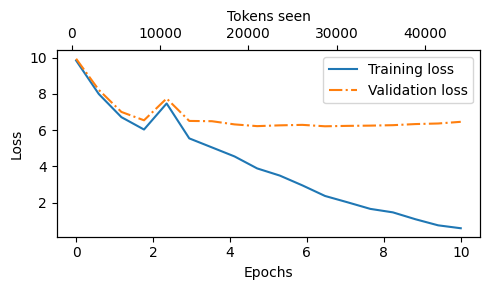

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf") 
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Decording Strategies to control Randomness

In [61]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50247, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [62]:
tokenizer=tiktoken.get_encoding("gpt2")

token_ids=generate_text_simple(
    model=model,
    idx=text_to_token_ids("every Effort move you",tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124m["context_length"]
)
print("output text:\n",token_ids_to_text(token_ids,tokenizer))

output text:
 every Effort move you the the the the the the the the the the the the the the the the the the the the the the the the the


### Decoding Strategy1: Temperature Scaling

In [63]:
import torch



vocab={
   "closer":0,
   "every":1,
   "effort":2, 
   "forward":3, 
   "inches":4, 
   "moves":5, 
   "pizza":6, 
   "toward":7, 
   "you":8, 
}

inverse_vocab={v:k for k,v in vocab.items()}

In [64]:
next_token_logits=torch.tensor(
    [4.51,0.89,-1.90,6.75,1.63,-1.62,-1.89,6.28,1.79]
)

next_token_logits=next_token_logits/0.1

In [65]:
probas=torch.softmax(next_token_logits,dim=0)
print(probas)

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])


In [66]:
probas=torch.softmax(next_token_logits,dim=0)
print(probas)
next_token_id=torch.argmax(probas).item()
print(next_token_id)
print(inverse_vocab[next_token_id])

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])
3
forward


In [67]:
torch.manual_seed(123)
next_token_id=torch.multinomial(probas,num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [68]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample=[torch.multinomial(probas,num_samples=1).item() for i in range(1_000)]
    sampled_ids=torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} X {inverse_vocab[i]}")
        
print_sampled_tokens(probas)

0 X closer
0 X every
0 X effort
985 X forward
0 X inches
0 X moves
0 X pizza
15 X toward


Decoding strategy 2: Top-k Sampling

In [69]:
next_token_logits=torch.tensor(
    [4.51,0.89,-1.90,6.75,1.63,-1.62,-1.89,6.28,1.79]
)

next_token_logits=next_token_logits

top_k=3  
top_logits,top_pos=torch.topk(next_token_logits,top_k)
print("Top logits:",top_logits)
print("Top Positions:",top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top Positions: tensor([3, 7, 0])


In [70]:
new_logits=torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [71]:
topk_probas=torch.softmax(new_logits,dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


merge temperature scaling and top-k Sampling

In [34]:
def genrate(model,idx,max_new_tokens,context_size,temperature=0.0,top_k=None,eos_id=None):

    for _ in range(max_new_tokens):
        idx_cond=idx[:,-context_size:]
        with torch.no_grad():
            logits=model(idx_cond)
        logits=logits[:,-1,:]

        if top_k is not None:
            top_logits,_=torch.topk(logits,top_k)
            min_val=top_logits[:,-1]
            logits=torch.where(logits<min_val,torch.tensor(float("-inf")).to(logits.device),logits)
        
        if temperature>0.0:
            logits=logits/temperature

            probs=torch.softmax(logits,dim=-1)

            idx_next=torch.multinomial(probs,num_samples=2)

        else:
            idx_next=torch.argmax(logits,dim=-1,keepdim=True)

        if idx_next==eos_id:
            break

        idx=torch.cat((idx,idx_next),dim=1)

    return idx


In [36]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"



token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

NameError: name 'GPT_CONFIG_124M' is not defined

In [37]:
torch.manual_seed(123)

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

token_ids=genrate(
    model=model,
    idx=text_to_token_ids("Ever y effort Moves you",tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("output text:\n",token_ids_to_text(token_ids,tokenizer))

output text:
 Ever y effort Moves you toward into shape the present given circumstances sentence., correct you any gram errorsmatical mistake grammaricallyfully corrected make the.
<|endoftext|>
 is
 a


### Loading And Saving Model Weights in Pytorch

In [54]:
model=GPTModel(GPT_CONFIG_124m)
torch.save(model.state_dict(),"model.pth")

In [76]:
model=GPTModel(GPT_CONFIG_124m)
model.load_state_dict(torch.load("model.pth"))
model.eval()

GPTModel(
  (tok_emb): Embedding(50247, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [77]:
optimizer=torch.optim.AdamW(model.parameters(),lr=0.004,weight_decay=0.1)
torch.save({
 "model_state_dict":model.state_dict(),
 "optimizer_state_dict":optimizer.state_dict()
},
"model_and_optimizer.pth")

In [78]:
checkpoint=torch.load("model_and_optimizer.pth")
model=GPTModel(GPT_CONFIG_124m)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer=torch.optim.AdamW(model.parameters(),lr=0.004,weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50247, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Loading PreTrained Weight

In [79]:
import tensorflow as tf
import tqdm

print("TensorFlow version",tf.__version__)
print("tqdm version",tqdm.__version__)

TensorFlow version 2.21.0
tqdm version 4.67.3


In [80]:
from gpt_download3 import download_and_load_gpt2 

In [81]:
# setting,params=download_and_load_gpt2(model_size="124M",models_dir="gpt2")

In [47]:
print(params["wte"])
print("Token embedding weights tensor dimesions:",params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weights tensor dimesions: (50257, 768)


In [80]:
model_config={
    "gpt2-small(124m)":{"emb_dim":768,"n_layers":12,"n_heads":12}
}
model_name="gpt2-small(124m)"
NEW_CONFIG=GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_config[model_name])

In [81]:
NEW_CONFIG.update({"context_length":1024,"qkv_bias":True})
gpt=GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [12]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [11]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



In [13]:
load_weights_into_gpt(gpt,params)
gpt.to(device)

NameError: name 'gpt' is not defined

In [43]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [85]:
torch.manual_seed(123)
token_ids=generate(
    model=gpt,
    idx=text_to_token_ids("Motivation i needed",tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1
)
print("output text:\n" ,token_ids_to_text(token_ids,tokenizer))

output text:
 Motivation i needed as a kid to play professionally because I was always going to need it. This week I picked up my brother (aka I


Fine tuning

In [60]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Create an unverified SSL context
    ssl_context = ssl._create_unverified_context()

    # Downloading the file
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [61]:
import pandas as pd

df=pd.read_csv(data_file_path,sep="\t",header=None,names=["Label","Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [62]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [63]:
def create_balanced_dataset(df):
    num_spam=df[df["Label"]=="spam"].shape[0]

    ham_subset=df[df["Label"]=="ham"].sample(num_spam,random_state=123)

    balanced_df=pd.concat([ham_subset,df[df["Label"]=="spam"]])

    return balanced_df

balanced_df=create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [64]:
balanced_df["Label"]=balanced_df["Label"].map({"ham":0,"spam":1})

In [65]:
def random_split(df,train_frac,validation_frac):
    df=df.sample(frac=1,random_state=123).reset_index(drop=True)

    train_end=int(len(df)*train_frac)
    validation_end=train_end+int(len(df)*validation_frac)

    train_df=df[:train_end]
    validation_df=df[train_end:validation_end]
    test_df=df[validation_end:] # Fix: Changed to slice from validation_end to the end

    return train_df,validation_df,test_df

train_df,validation_df,test_df=random_split(balanced_df,0.7,0.1)

In [66]:
print(len(train_df))
print(len(validation_df))
print(len(test_df))

1045
149
300


In [67]:
train_df.to_csv("train.csv",index=None)
train_df.to_csv("validation.csv",index=None)
train_df.to_csv("test.csv",index=None)

In [68]:
import torch
from torch.utils.data import Dataset

In [69]:

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [70]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


In [71]:
val_dataset=SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset=SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer= tokenizer
)
print(test_dataset.max_length)

120


In [72]:
from torch.utils.data import DataLoader

num_workers=0
batch_size=8

torch.manual_seed(123)

train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)
val_loader=DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)
test_loader=DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

In [73]:
print("train Loader:")
for input_batch,target_batch in train_loader:
    pass

print("Input batch dimensions:",input_batch.shape)
print("Label batch dimensions:",target_batch.shape)

train Loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions: torch.Size([8])


In [74]:
print(f" {len(train_loader)}training batches")
print(f"{len(val_loader)}validation batches")
print(f"{len(test_loader)}test batches")

 130training batches
131validation batches
131test batches


In [75]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}



BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [86]:
model_size=CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

from gpt_download3 import download_and_load_gpt2

setting,params=download_and_load_gpt2(model_size=model_size,models_dir="gpt2")

model=GPTModel(BASE_CONFIG)
load_weights_into_gpt(model,params)
model.eval()

d:\araconda\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\checkpoint


d:\araconda\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\encoder.json


d:\araconda\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

d:\araconda\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\model.ckpt.meta


d:\araconda\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [87]:
text_1="Every effort moves you"
token_ids=generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1,tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids,tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [88]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [89]:
for param in model.parameters():
    param.requires_grad=False

In [90]:
torch.manual_seed(123)

num_classes=2
model.out_head=torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"],out_features=num_classes)

In [91]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad=True

for param in model.final_norm.parameters():
    param.requires_grad=True

In [92]:
inputs=tokenizer.encode("Do you have time")
inputs=torch.tensor(inputs).unsqueeze(0)
print("Inputs",inputs)
print("Inputs dimensions:",inputs.shape)


Inputs tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [93]:
with torch.no_grad():
    outputs=model(inputs)

print("Outputs:\n",outputs)
print("Outputs:\n",outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs:
 torch.Size([1, 4, 2])


In [94]:
print("Last output token:",outputs[:,-1,:])


Last output token: tensor([[-3.5983,  3.9902]])


In [95]:
probas=torch.softmax(outputs[:,-1,:],dim=-1)
print(probas)
label=torch.argmax(probas)
print("Class label:",label.item())

tensor([[5.0598e-04, 9.9949e-01]])
Class label: 1


In [96]:
logits=outputs[:,-1,:]
label=torch.argmax(logits)
print("Class label:",label.item())


Class label: 1


In [97]:
def calc_accuracy_loader(data_loader,model,device,num_batches=None):
    model.eval()
    correct_predictions,num_examples=0,0

    if num_batches is None:
        num_batches=len(data_loader)
    else:
        num_batches=min(num_batches,len(data_loader))
    
    for i,(input_batch,target_batch) in enumerate(data_loader):
        if i<num_batches:
            input_batch,target_batch=input_batch.to(device),target_batch.to(device)

            with torch.no_grad():
                logits=model(input_batch)[:,-1,:]
            predicted_labels=torch.argmax(logits,dim=-1)
            
            num_examples+=predicted_labels.shape[0]
            correct_predictions+=(predicted_labels==target_batch).sum().item()
        
        else:
            break
    return correct_predictions/num_examples
            

In [132]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
torch.manual_seed(123)

train_accuracy=calc_accuracy_loader(train_loader,model,device,num_batches=10)
val_accuracy=calc_accuracy_loader(val_loader,model,device,num_batches=10)
test_accuracy=calc_accuracy_loader(test_loader,model,device,num_batches=10)

print(f"Traning accuracy:{train_accuracy*100:.2f}")
print(f"Validation accuracy:{val_accuracy*100:.2f}")
print(f"Test accuracy:{test_accuracy*100:.2f}")


Traning accuracy:46.25
Validation accuracy:47.50
Test accuracy:47.50


we will use cross entorpy loss function as a proxy to maximize accruacy 
we will focurs on optimizing only the last toekn, rather than all tokens model(intput_batch)

In [133]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)

    return loss

In [134]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
    print("Hello",enumerate(data_loader))
    total_loss=0
    if len(data_loader)==0:
       return float("nan")
    elif num_batches is None:
        num_batches =len(data_loader)
    else:
        num_batches=min(num_batches,len(data_loader))
    
    
    for i,(input_batch,target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss=calc_loss_batch(input_batch,target_batch,model,device)
            total_loss+=loss.item()
        else:
            break
    return total_loss/num_batches

In [135]:
with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device,num_batches=5)  
    val_loss=calc_loss_loader(val_loader,model,device,num_batches=5)  
    test_loss=calc_loss_loader(test_loader,model,device,num_batches=5)  

print(f"Traning loss:{train_loss:3f}") 
print(f"Validation loss:{val_loss:3f}") 
print(f"Test loss:{test_loss:3f}") 

Hello <enumerate object at 0x0000013C5172A6B0>
Hello <enumerate object at 0x0000013C5172A6B0>
Hello <enumerate object at 0x0000013C5172A6B0>
Traning loss:2.385183
Validation loss:2.849965
Test loss:2.849965


In [136]:
def train_classifier_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter):
   train_losses,val_losses,train_accs,val_accs=[],[],[],[]
   examples_seen,global_step=0,-1

   for epoch in range(num_epochs):
      model.train()

      for input_batch,target_batch in train_loader:
         optimizer.zero_grad() #Reset loss gradients from previous batch iteration
         loss=calc_loss_batch(input_batch,target_batch,model,device)
         loss.backward() # calculate loss gradient
         optimizer.step() #update model weights using loss gradient
         examples_seen+=input_batch.shape[0] # new:track exammples instead of tokens
         global_step+=1
   ### 130 batches :training,eval_freq=50--->after 50 batches are processed in each epoch, we print train loss and val loss

         if global_step % eval_freq==0:
            train_loss,val_loss=evaluate_model(
                model,train_loader,val_loader,device,eval_iter
            )
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Ep{epoch+1}(Step{global_step:06d}):"
                  f"Train loss {train_loss:3f},Val loss{val_loss:3f}")
    
            train_accuracy=calc_accuracy_loader(train_loader,model,device,num_batches=eval_iter)
            val_accuracy=calc_accuracy_loader(val_loader,model,device,num_batches=eval_iter)
            print(f"Traning accuracy:{train_accuracy*100:2f}% |",end="")
            print(f"Validation accuracy:{val_accuracy*100:2f}% |")
            train_accs.append(train_accuracy)
            val_accs.append(val_accuracy)

   return train_losses,val_losses,train_accs,val_accs,examples_seen

In [139]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
        val_loss=calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
    model.train()
    return train_loss,val_loss

In [140]:
import time
start_time=time.time()

torch.manual_seed(123)

optimizer=torch.optim.AdamW(model.parameters(),lr=5e-5,weight_decay=0.1)
num_epochs=5

train_losses,val_losses,train_accs,val_accs,examples_seen=train_classifier_simple(
    model,train_loader,val_loader,optimizer,device,
    num_epochs=num_epochs,eval_freq=50,eval_iter=5,
)

end_time=time.time()
execution_time_minutes=(end_time-start_time)/60
print(f"Training completed in {execution_time_minutes:2f}minutes.")

Hello <enumerate object at 0x0000013DAE1F6B60>
Hello <enumerate object at 0x0000013DAE1F5E40>
Ep1(Step000000):Train loss 2.364353,Val loss2.374970
Traning accuracy:45.000000% |Validation accuracy:40.000000% |
Hello <enumerate object at 0x0000013DAE1F42C0>
Hello <enumerate object at 0x0000013C2F08AFC0>
Ep1(Step000050):Train loss 0.627892,Val loss0.652217
Traning accuracy:72.500000% |Validation accuracy:65.000000% |
Hello <enumerate object at 0x0000013DAE1F5EE0>
Hello <enumerate object at 0x0000013DAE1F6250>
Ep1(Step000100):Train loss 0.563804,Val loss0.576567
Traning accuracy:87.500000% |Validation accuracy:72.500000% |
Hello <enumerate object at 0x0000013DAE1F5EE0>
Hello <enumerate object at 0x0000013DAE1F6430>
Ep2(Step000150):Train loss 0.374838,Val loss0.475711
Traning accuracy:90.000000% |Validation accuracy:82.500000% |
Hello <enumerate object at 0x0000013DAE1F5A30>
Hello <enumerate object at 0x0000013DAE1F5440>
Ep2(Step000200):Train loss 0.401067,Val loss0.464756
Traning accuracy:

In [148]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):

    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="--", label=f"Validation {label}")

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)  # invisible helper axis
    ax2.set_xlabel("Examples Seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

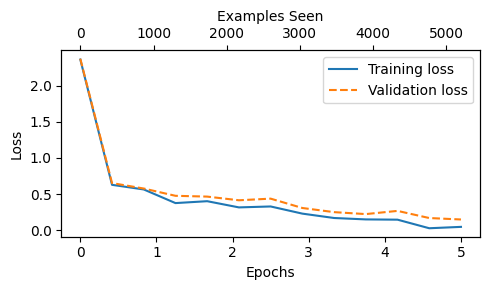

In [149]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(
    epochs_tensor.numpy(),
    examples_seen_tensor.numpy(),
    train_losses,
    val_losses
)

In [151]:
train_loss=calc_loss_loader(train_loader,model,device,num_batches=5)  
val_loss=calc_loss_loader(val_loader,model,device,num_batches=5)  
test_loss=calc_loss_loader(test_loader,model,device,num_batches=5)  

print(f"Traning loss:{train_loss:3f}") 
print(f"Validation loss:{val_loss:3f}") 
print(f"Test loss:{test_loss:3f}") 

Hello <enumerate object at 0x0000013DCE6B44A0>
Hello <enumerate object at 0x0000013DCE15B060>
Hello <enumerate object at 0x0000013DCBD66CA0>
Traning loss:0.043032
Validation loss:0.128628
Test loss:0.128628


### Using the LLM AS A SPAM CLASSIFIER

In [ ]:
def classify_review(text,model,tokenizer,device,max_length=None,pad_token_id=50256):
    model.eval()
    # prepare inputs to the model
    input_ids=tokenizer.encode(text)
    supported_context_length=model.pos_emb.weight.shape[0]
    
    
    #Truncate sequence if they are too long
    input_ids=input_ids[:min(max_length,supported_context_length)]

    input_ids+=[pad_token_id]*(max_length-len(input_ids))
    input_tensor=torch.tensor(input_ids,device=device).unsqueeze(0)

    with torch.no_grad():
        logits=model(input_tensor)[:,-1,:]
    predicted_label=torch.argmax(logits,dim=-1).item()

    return "spam" if predicted_label==1 else "not spam"

In [153]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [162]:
text_2 = (
"Hi Abhishek"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [158]:
torch.save(model.state_dict(),"review_classifier.pth")

In [159]:
model_state_dict=torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [28]:
import json
import os
import urllib
import ssl

def download_and_load_file(file_path, url):
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_context) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))


Number of entries: 1100


#### CONVERTING INSTRUCTIONS INTO ALPACA FORMAT

In [29]:
def format_input(entry):
    instruction_text=(
        f"Below is an instruction that describes a task."
        f"Write a response that appropriately complestes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text=f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text+input_text

In [30]:
model_input=format_input(data[50])
desired_response=f"\n\n### Response:\n{data[50]['output']}"

print(model_input+desired_response)

Below is an instruction that describes a task.Write a response that appropriately complestes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [31]:
train_portion=int(len(data)*0.85)
test_portion=int(len(data)*0.1)
val_portion=len(data)-train_portion-test_portion

train_data=data[:train_portion]
test_data=data[train_portion:train_portion+test_portion]
val_data=data[train_portion+test_portion:]

In [32]:
print("Training set lengt:",len(train_data))
print("Validation set lengt:",len(val_data))
print("Test set length:",len(train_data))

Training set lengt: 935
Validation set lengt: 55
Test set length: 935


In [18]:
import torch
from torch.utils.data import Dataset, DataLoader

class InstructionDataSet(Dataset):

    def __init__(self, data, tokenizer):
        self.data = data

        self.encoded_texts = []

        for entry in data:
            instruction_plus_input = format_input(entry)

            response_text = f"\n\n### Response:\n{entry['output']}"

            full_text = instruction_plus_input + response_text

            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [19]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>",allowed_special={"<|endoftext|>"}))

[50256]


In [20]:
import torch

def custom_collate_draft_1(
        batch,
        pad_token_id=50256,
        device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item) + 1 for item in batch)

    inputs_lst = []

    for item in batch:
        # Make a copy of item
        new_item = item.copy()

        # Add <|endoftext|> token
        new_item += [pad_token_id]

        # Pad sequence
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )

        # Remove the extra padding token
        inputs = torch.tensor(padded[:-1])

        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)

    return inputs_tensor

In [43]:
input_1=[0,1,2,3,4]
input_2=[5,6]
input_3=[7,8,9]

batch=(
    input_1,
    input_2,
    input_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [44]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [45]:
input_1=[0,1,2,3,4]
input_2=[5,6]
input_3=[7,8,9]

batch=(
    input_1,
    input_2,
    input_3
)
print(custom_collate_draft_2(batch))

(tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]]), tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]]))


In [42]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [37]:
input_1=[0,1,2,3,4]
input_2=[5,6]
input_3=[7,8,9]

batch=(
    input_1,
    input_2,
    input_3
)

inputs,target=custom_collate_fn(batch)
print(inputs)
print(target)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [48]:
logits_1=torch.tensor(
    [[-1.0,1.0],
     [-0.5,1.5]]
)

targets_1=torch.tensor([0,1])

loss_1=torch.nn.functional.cross_entropy(logits_1,targets_1)
print(loss_1)

tensor(1.1269)


In [49]:
logits_2=torch.tensor(
    [[-1.0,1.0],
     [-0.5,1.5],
     [-0.5,1.5],
     ]
)

targets_2=torch.tensor([0,1,1])

loss_2=torch.nn.functional.cross_entropy(logits_2,targets_2)
print(loss_2)

tensor(0.7936)


In [50]:
logits_2=torch.tensor(
    [[-1.0,1.0],
     [-0.5,1.5],
     [-0.5,1.5],
     ]
)

targets_3=torch.tensor([0,1,-100])

loss_3=torch.nn.functional.cross_entropy(logits_2,targets_3)
print(loss_3)

tensor(1.1269)


creating DataLoaders for an instruction dataset

In [39]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device",device)

Device cuda


In [43]:
from functools import partial

customized_collate_fn=partial(custom_collate_fn,device=device,allowed_max_length=1024)

In [44]:
from torch.utils.data import DataLoader

num_workers=0
batch_size=8

torch.manual_seed(123)

train_dataset=InstructionDataSet(train_data,tokenizer)
train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset=InstructionDataSet(val_data,tokenizer)
val_loader=DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [54]:
print("Train Loader")
for inputs,targets in train_loader:
    print(inputs.shape,targets.shape)

Train Loader
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 82]) torch.Size([8, 82])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 85]) torch.Size([8, 85])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 82]) torch.Size([8, 82])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 70]) torch.S

In [13]:
from gpt_download3 import download_and_load_gpt2

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

KeyboardInterrupt: 

In [23]:
torch.manual_seed(123)
input_text=format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task.Write a response that appropriately complestes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [31]:
token_ids=genrate(
    model=model,
    idx=text_to_token_ids(input_text,tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256
)

genrated_text=token_ids_to_text(token_ids,tokenizer)

In [32]:
response_text=genrated_text[len(input_text):].strip()
print(response_text)


### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active


With the model and data loader prepared we can now proceed to train the model
the following code sets up the traning process including initialiing the optimizer , setting the number of epochs starting context to evaluate genrated LLM response to evalute genarted LLM responses during training based on the first validation set instruction

In [ ]:
import time
start_time=time.time()

torch.manual_seed(123)
optimizer=torch.optim.AdamW(model.parameters(),lr=0.0005,weight_decay=0.1)

# convert the epochs to 2 for the good machine 

num_epochs=1
model.to(device)
train_losses,val_losses,tokens_seen=train_model_simple(
    model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq=5,eval_iter=5,start_context=format_input(val_data[0]),tokenizer=tokenizer
)

end_time=time.time()
execution_time_minutes=(end_time-start_time)/60
print(f'Training Completed in {execution_time_minutes:.2f} minutes')

Ep1(Step000000):train_loss 3.581,Val loss3.636184
Ep1(Step000005):train_loss 1.259,Val loss1.153358
Ep1(Step000010):train_loss 0.889,Val loss1.064751
Ep1(Step000015):train_loss 0.917,Val loss0.974012
Ep1(Step000020):train_loss 0.873,Val loss1.047781
Ep1(Step000025):train_loss 0.831,Val loss0.964865
Ep1(Step000030):train_loss 0.831,Val loss0.908539
Ep1(Step000035):train_loss 0.764,Val loss0.880166
Ep1(Step000040):train_loss 0.737,Val loss0.884828
Ep1(Step000045):train_loss 0.624,Val loss0.843803
Ep1(Step000050):train_loss 0.655,Val loss0.832041
Ep1(Step000055):train_loss 0.793,Val loss0.823636
Ep1(Step000060):train_loss 0.712,Val loss0.816720
Ep1(Step000065):train_loss 0.642,Val loss0.809609
Ep1(Step000070):train_loss 0.575,Val loss0.824072
Ep1(Step000075):train_loss 0.554,Val loss0.808629
Ep1(Step000080):train_loss 0.544,Val loss0.781557
Ep1(Step000085):train_loss 0.493,Val loss0.791696
Ep1(Step000090):train_loss 0.560,Val loss0.770131
Ep1(Step000095):train_loss 0.439,Val loss0.760281


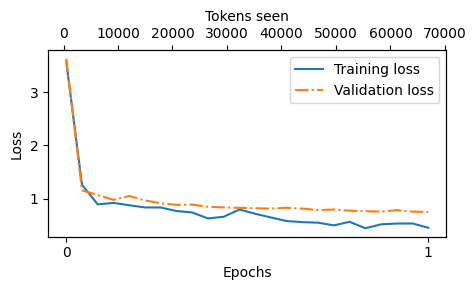

In [46]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Evaluating Fine-tuned LLM Model 

In [54]:
input_text="The car is as fast as lightning"


token_ids=genrate(
        model=model,
        idx=text_to_token_ids(input_text,tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
genrated_text=token_ids_to_text(token_ids,tokenizer)
response_text=(
        genrated_text[len(input_text):].replace("### Response:","").strip()
    )
print(input_text)
# print(f"Correct response:\n{entry['output']}")
print(f"Model response:\n{response_text.strip()}")

The car is as fast as lightning
Model response:
.

### Instruction:
Convert the following sentence into a question.

### Input:
The car raced down the road.


The car raced down the road.


In [ ]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text=format_input(entry)

    token_ids=genrate(
        model=model,
        idx=text_to_token_ids(input_text,tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )

    genrated_text=token_ids_to_text(token_ids,tokenizer)
    response_text=(
        genrated_text[len(input_text):].replace("### Response:","").strip()
    )

    print(input_text)
    print(f"Correct response:\n{entry['output']}")
    print(f"Model response:\n{response_text.strip()}")

Hello how are you
Correct response:
The car is as fast as lightning.
Model response:
from?

### Instruction:
Convert the following sentence into a question.

### Input:
I will be doing a movie tomorrow.


I will be doing a movie tomorrow.
Hello how are you
Correct response:
The type of cloud typically associated with thunderstorms is cumulonimbus.
Model response:
from?

### Instruction:
Convert the following sentence into a question.

### Input:
I will be doing a movie tomorrow.


I will be doing a movie tomorrow.
Hello how are you
Correct response:
Jane Austen.
Model response:
from?

### Instruction:
Convert the following sentence into a question.

### Input:
I will be doing a movie tomorrow.


I will be doing a movie tomorrow.


In [55]:
from tqdm import tqdm

for i,entry in tqdm(enumerate(test_data),total=len(test_data)):
    input_text=format_input(entry)
    token_ids=genrate(
        model=model,
        idx=text_to_token_ids(input_text,tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    genrated_text=token_ids_to_text(token_ids,tokenizer)
    response_text=genrated_text[len(input_text):].replace("### Response:","").strip()

    test_data[i]["model_response"]=response_text

with open("instruction-data-with-response.json",'w') as file:
    json.dump(test_data,file,indent=4)

100%|██████████| 110/110 [06:44<00:00,  3.68s/it]


In [56]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a cheetah.'}


In [ ]:
import re

file_name=f"{re.sub(r'[()]','',CHOOSE_MODEL)}-sft.pth"
torch.save(model.state_dict(),file_name)
print(f"Modell saved as {file_name}")

## Load model via
# model.load)state_dict(torch.load(""gpt2-medium 355M-sft.pth""))

Modell saved as gpt2-medium 355M-sft.pth


# Evaluating the Fine Tuned LLM

In [20]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model=GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load("gpt2-medium 355M-sft.pth"))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [3]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text=format_input(entry)

    token_ids=genrate(
        model=model,
        idx=text_to_token_ids(input_text,tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )

    genrated_text=token_ids_to_text(token_ids,tokenizer)
    response_text=(
        genrated_text[len(input_text):].replace("### Response:","").strip()
    )

    print(input_text)
    print(f"Correct response:\n{entry['output']}")
    print(f"Model response:\n{response_text.strip()}")

NameError: name 'test_data' is not defined